# 01_Linear_Regression_Ames_Housing_Industry.ipynb

## AI/ML Engineer Training Series

### Objective

Build an end-to-end **Linear Regression** model using the **Ames Housing dataset** following an **industry-standard machine learning workflow**.

### Workflow

1. Problem Understanding
2. Import Libraries
3. Load Dataset
4. Exploratory Data Analysis (EDA)
5. Missing Value Analysis
6. Numerical vs Categorical Features
7. Train/Test Split
8. ColumnTransformer + OneHotEncoder + StandardScaler
9. Pipeline Construction
10. Model Training
11. Cross-Validation
12. Hyperparameter Tuning
13. Model Evaluation (R², MAE, RMSE)
14. Train vs Test Analysis
15. Model Interpretation
16. Interview Questions
17. Key Takeaways


In [4]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("datasets/train.csv")

# Basic inspection
display(df.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [11]:
print("shape:",df.shape)
print("coloumns",df.columns)
print("coloumns",len(df.columns))

shape: (1460, 81)
coloumns Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
     

In [13]:
print("Target","SalePrice")

Target SalePrice


In [14]:
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [15]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=["int64","float64"]).columns
cat_cols =df.select_dtypes(include=["object"]).columns

print("Numerical features:",len(num_cols))
print("Categorical features:",len(cat_cols))

Numerical features: 38
Categorical features: 43


In [17]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing= missing[missing>0]

print("\nTop 10 columns with missing values:")
print(missing.head(10))


Top 10 columns with missing values:
PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageYrBlt      81
GarageCond       81
GarageType       81
dtype: int64


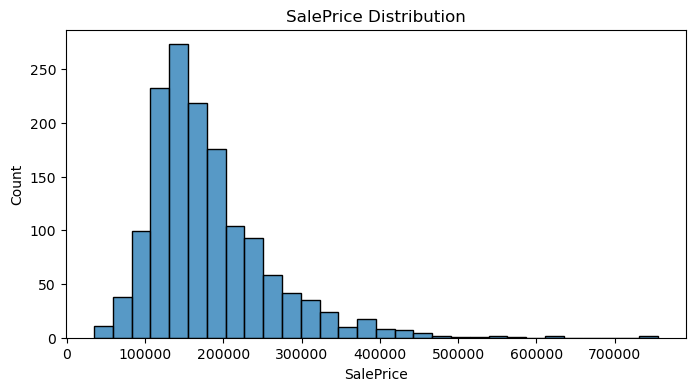

In [18]:
# Target distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df["SalePrice"], bins=30)
plt.title("SalePrice Distribution")
plt.show()

In [19]:
# Missing value percentage
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

missing_summary = pd.DataFrame({
    "MissingCount": df.isnull().sum(),
    "MissingPercent": (df.isnull().sum() / len(df) * 100)
})

missing_summary = missing_summary[missing_summary["MissingCount"] > 0]
missing_summary = missing_summary.sort_values("MissingPercent", ascending=False)

missing_summary.head(10)

,MissingCount,MissingPercent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [20]:
drop_cols = ["PoolQC", "MiscFeature", "Alley", "Fence"]
df = df.drop(columns=drop_cols)

# Features and target
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

print("Feature shape:", X.shape)
print("Target shape :", y.shape)

Feature shape: (1460, 76)
Target shape : (1460,)


In [23]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1168, 76)
X_test : (292, 76)
y_train: (1168,)
y_test : (292,)


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify column types from training data
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numerical columns: 37
Categorical columns: 39


In [26]:
numeric_transformer = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scalar",StandardScaler())
])

In [27]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [28]:
preprocessor = ColumnTransformer([
    ("num",numeric_transformer,num_cols),
    ("cat",categorical_transformer,cat_cols)
])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scalar', StandardScaler())]),
                                 Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'B...
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object'))])

In [29]:
from sklearn.linear_model import LinearRegression

# Full pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrS...
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

In [30]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrS...
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

In [31]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print(y_train_pred[:5])
print(y_test_pred[:5])

[146082.60755543 171848.85020337  85246.00667006 165346.58463689
 165463.39930586]
[155936.02406449 352286.91647726  89641.55187519 174628.96116611
 321762.81663207]


In [32]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = root_mean_squared_error(y_train, y_train_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)

print("Train R² :", round(train_r2, 4))
print("Test R²  :", round(test_r2, 4))
print("Train MAE:", round(train_mae, 2))
print("Test MAE :", round(test_mae, 2))
print("Train RMSE:", round(train_rmse, 2))
print("Test RMSE :", round(test_rmse, 2))

Train R² : 0.934
Test R²  : 0.8844
Train MAE: 12856.15
Test MAE : 18411.76
Train RMSE: 19845.42
Test RMSE : 29774.95


## Train vs Test Analysis

| Metric |  Train |   Test |
| ------ | -----: | -----: |
| R²     |  0.934 |  0.884 |
| MAE    | 12,856 | 18,412 |
| RMSE   | 19,845 | 29,775 |

### Interpretation

* The model explains **93.4%** of the variance in the training data.
* The model explains **88.4%** of the variance in the test data.
* The **R² gap is only 0.05**, indicating **good generalization**.
* Test MAE and RMSE are higher than training metrics, which is expected because the model is evaluated on unseen data.
* Overall, the model shows **no severe overfitting** and performs well on this regression task.


In [33]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("CV Scores:", cv_scores)
print("Mean CV R²:", cv_scores.mean())
print("Std CV R² :", cv_scores.std())

CV Scores: [0.8824446  0.70473812 0.6494847  0.69167234 0.8631694 ]
Mean CV R²: 0.7583018316128409
Std CV R² : 0.09545508137659017


## Cross-Validation Analysis

```text
CV Scores: [0.882, 0.705, 0.649, 0.692, 0.863]
Mean CV R²: 0.758
Std CV R² : 0.095
```

### Interpretation

* The average cross-validation R² is **0.758**, meaning the model explains approximately **75.8% of the variance** across different training/validation splits.
* The standard deviation (**0.095**) indicates that performance varies across folds.
* This suggests that the model is **reasonably good but not perfectly stable**, likely because different subsets of houses have different characteristics (neighborhoods, house sizes, renovation status, etc.).
* Cross-validation provides a **more reliable estimate of generalization** than a single train/test split.


In [34]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

param_grid = {
    "regressor__alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    ridge_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Alpha:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

Best Alpha: {'regressor__alpha': 10}
Best CV R²: 0.8171776569263172


# Project Conclusion

## Model Comparison

| Model             | Mean CV R² |
| ----------------- | ---------: |
| Linear Regression |      0.758 |
| Ridge Regression  |      0.817 |

Ridge Regression achieved a **higher cross-validation R² score**, indicating that **regularization improved the model’s ability to generalize** across different subsets of the data.

## Best Hyperparameter

```text
Best Alpha: 10
Best CV R²: 0.817
```

The optimal value of `alpha` was **10**, which suggests that a moderate level of regularization was beneficial for this dataset.

## Key Learnings

* Performed exploratory data analysis on a real-world housing dataset.
* Identified numerical and categorical features.
* Analyzed missing values and selected appropriate preprocessing strategies.
* Built a **ColumnTransformer** for separate numerical and categorical preprocessing.
* Applied **SimpleImputer**, **StandardScaler**, and **OneHotEncoder**.
* Combined preprocessing and modeling using a **Pipeline**.
* Evaluated the model using **R², MAE, and RMSE**.
* Performed **5-fold cross-validation** to obtain a reliable estimate of model performance.
* Used **GridSearchCV** to tune the Ridge Regression hyperparameter (`alpha`).
* Compared Linear Regression and Ridge Regression and selected the better-performing model.

## Business Interpretation

The final Ridge Regression model can explain approximately **81.7% of the variation in house prices**, making it a strong baseline model for residential property price prediction.

## Interview Takeaways

* **Why use a Pipeline?**

  * Prevents data leakage.
  * Keeps preprocessing and modeling together.
  * Makes cross-validation and deployment reliable.

* **Why use ColumnTransformer?**

  * Applies different preprocessing steps to numerical and categorical features.

* **Why use median imputation?**

  * Median is robust to outliers commonly found in housing data.

* **Why use OneHotEncoder?**

  * Linear Regression requires numerical inputs, so categorical variables must be encoded.

* **Why use cross-validation?**

  * A single train/test split may be misleading; cross-validation provides a more robust estimate of model generalization.

* **Why did Ridge outperform Linear Regression?**

  * Ridge adds L2 regularization, reducing overfitting and improving generalization.

## Final Result

This notebook demonstrates an **industry-standard machine learning workflow** for a regression problem using the **Ames Housing dataset**, including preprocessing, pipelines, cross-validation, hyperparameter tuning, and model evaluation.


In [37]:
test_df = pd.read_csv("datasets/test.csv")

print(test_df.shape)
test_df.head()

(1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [38]:
best_model = grid.best_estimator_

predictions = best_model.predict(test_df)

print(predictions[:5])

[101860.92714525 147898.84931189 168169.86662191 186163.50891725
 208942.97335851]


In [39]:
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": predictions
})

submission.head()

,Id,SalePrice
0,1461,101860.927145
1,1462,147898.849312
2,1463,168169.866622
3,1464,186163.508917
4,1465,208942.973359


In [40]:
submission.to_csv("submission.csv", index=False)

print("Kaggle submission file created successfully!")

Kaggle submission file created successfully!


## Production Prediction

The trained Ridge Regression pipeline was used to generate predictions for the unseen `test.csv` dataset.

### Steps

1. Loaded `test.csv`.
2. Applied the trained preprocessing pipeline automatically.
3. Generated house price predictions.
4. Created a Kaggle-compatible `submission.csv` file containing:

   * `Id`
   * `SalePrice`

This demonstrates the **complete machine learning workflow from raw data to production-ready predictions**, which is the standard approach used in real-world ML projects and Kaggle competitions.


# Dataset Description

## Ames Housing Dataset (Kaggle)

**Competition:** House Prices: Advanced Regression Techniques

**Source:** Kaggle

**Link:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

### Overview

The Ames Housing dataset contains detailed information about residential home sales in **Ames, Iowa (USA)**. The goal is to predict the **final sale price (`SalePrice`)** of each house using a wide range of property characteristics.

### Dataset Information

* **Training rows:** 1,460
* **Test rows:** 1,459
* **Features:** 80 input features
* **Target variable:** `SalePrice`

### Feature Categories

The dataset includes both **numerical** and **categorical** variables, such as:

* Lot size and frontage
* Neighborhood
* Building type
* House style
* Overall quality and condition
* Year built and year remodeled
* Basement characteristics
* Garage information
* Exterior materials
* Porch, deck, and other property features

### Project Objective

Build a machine learning model capable of predicting the **market sale price of residential homes**. This notebook follows an **industry-standard regression workflow**, including:

1. Exploratory Data Analysis (EDA)
2. Missing Value Analysis
3. Numerical and Categorical Preprocessing
4. `ColumnTransformer` + `Pipeline`
5. `LinearRegression`
6. `Ridge Regression`
7. Cross-Validation
8. Hyperparameter Tuning with `GridSearchCV`
9. Model Evaluation using **R², MAE, and RMSE**
10. Production-style prediction on `test.csv` and generation of a Kaggle submission file

### Business Relevance

Accurate house price prediction is valuable for **real estate companies, banks, mortgage lenders, property investors, and housing market analysts**, enabling better pricing decisions, risk assessment, and investment planning.


## Kaggle Submission Result

The final Ridge Regression pipeline was used to generate predictions for the competition test set and submitted to Kaggle.

| Model            | Public Leaderboard Score (RMSLE) |
| ---------------- | -------------------------------: |
| Ridge Regression |                      **0.15895** |

This score represents a **strong baseline performance** for a first submission and demonstrates a complete end-to-end machine learning workflow, including preprocessing, pipeline construction, cross-validation, hyperparameter tuning, and production-style prediction generation.
